# Stevens Institute of Technology
## Summer 2025, EE 595
## Final Project: Time Series Price Prediction
### Authors: John Rizzo(LSTM), Matthew Kawaja(OLS), Leor Yomtobian (PatchTST)
### Professor: Shucheng Yu (shucheng.yu@stevens.edu)

## Preamble

In [1]:
import os
import time as tm
import datetime as dt
import random

# Data preparation
import pandas as pd
import numpy as np

from sklearn.preprocessing import MinMaxScaler #, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# For downloading the data from huggingface
# from huggingface_hub import hf_hub_download
from datasets import load_dataset

# ML
import tensorflow as tf
from tensorflow.keras.utils import plot_model
from keras.models import Sequential
from keras.layers import Dense, LSTM, Dropout

import torch
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn

# For OLS modeling
import statsmodels.api as sm

# Graphics library
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# For loading environment variables
from dotenv import load_dotenv

In [2]:
# Set random seed for reproducible results 
RANDOM_STATE=42
tf.random.set_seed(RANDOM_STATE)
torch.manual_seed(RANDOM_STATE)
torch.use_deterministic_algorithms(True)
np.random.seed(RANDOM_STATE)

# Requires huggingface cli login
STOCK_REPO_ID = "johnrizzo1/stocks_daily_price"
STOCK_RAW_DATA_FILE = "data/raw_stocks_daily_price.csv.gz"
STOCK_FILTERED_DATA_FILE = "data/filtered_stocks_daily_price.csv.gz"
BOND_REPO_ID = "johnrizzo1/bonds_daily_price"
BOND_RAW_DATA_FILE = "data/raw_bonds_daily_price.csv.gz"
BOND_FILTERED_DATA_FILE = "data/filtered_bonds_daily_price.csv.gz"
# EQUITY_TICKERS = ['AAPL', 'MSFT', 'GOOG']
EQUITY_TICKERS = ['AAPL']
# BOND_TICKERS = ['US10Y', 'US30Y', 'US5Y']
BOND_TICKERS = ['US10Y']

FILTER_DATE_START = dt.datetime(2022, 1, 1)
FILTER_DATE_END = dt.datetime(2025, 6, 28)

# LSTM Settings
WINDOW_SIZE = 7

# PatchTST Settings
INPUT_LEN = 60
FORECAST_LEN = 30
BATCH_SIZE = 64
EPOCHS = 150
PATCH_LEN = 15  # make sure INPUT_LEN % PATCH_LEN == 0
PATIENCE = 5
DELTA = 0.0001
NO_IMPROVEMENT_COUNT = 0
LEARNING_RATE = 0.0005

load_dotenv()

True

## Exploratory Data Analysis

### Equity

In [3]:
if os.path.exists(STOCK_RAW_DATA_FILE):
    equity_init_df = pd.read_csv(STOCK_RAW_DATA_FILE)
    equity_init_df.drop(columns='Unnamed: 0', inplace=True)
else:
    ds = load_dataset(STOCK_REPO_ID)
    training_set = ds['train']
    equity_init_df = training_set.to_pandas()
    equity_init_df.to_csv(STOCK_RAW_DATA_FILE)

equity_init_df.sort_values(by='date', inplace=True)

In [4]:
# Examining the Shape of the data
print("DataFrame shape:", equity_init_df.shape)

DataFrame shape: (24239949, 8)


In [5]:
# Information 
print("DataFrame info:")
print(equity_init_df.info())

DataFrame info:
<class 'pandas.core.frame.DataFrame'>
Index: 24239949 entries, 9024503 to 24239948
Data columns (total 8 columns):
 #   Column     Dtype  
---  ------     -----  
 0   symbol     object 
 1   date       object 
 2   open       float64
 3   high       float64
 4   low        float64
 5   close      float64
 6   volume     int64  
 7   adj_close  float64
dtypes: float64(5), int64(1), object(2)
memory usage: 1.6+ GB
None


In [6]:
print("First few rows:")
print(equity_init_df.head())

First few rows:
         symbol        date      open       high        low      close  \
9024503      GD  1962-01-02  0.000000   0.753125   0.728125   0.746875   
2269445      BA  1962-01-02  0.837449   0.837449   0.823045   0.823045   
14295746    MRK  1962-01-02  0.000000   0.397030   0.393165   0.395374   
6955471      ED  1962-01-02  0.000000  10.281250  10.125000  10.125000   
11807275    JNJ  1962-01-02  0.000000   0.223380   0.222222   0.223380   

           volume  adj_close  
9024503   2648000   0.171261  
2269445    352350   0.190931  
14295746   633830   0.066058  
6955471     25600   0.246745  
11807275        0   0.062022  


In [7]:
# Converting the date to a python datetime object.
equity_init_df['date'] = pd.to_datetime(equity_init_df['date'])

This is a lot of data.  For our purposes we can reduce this to a small set of companies such as Apple (APPL) Microsoft (MSFT) and Google (GOOG).  We will also limit this to a smaller time period as well.

In [8]:
# Filter by securities
equity_filtered_df = equity_init_df[equity_init_df['symbol'].isin(EQUITY_TICKERS)]

In [9]:
# Filter by date
equity_filtered_df = equity_filtered_df[(equity_filtered_df['date'] >= FILTER_DATE_START) & 
                          (equity_filtered_df['date'] <= FILTER_DATE_END)]

In [10]:
print(equity_filtered_df.shape)

(849, 8)


In [11]:
# Save the data checkpoint for paper reviews
equity_filtered_df.to_csv(STOCK_FILTERED_DATA_FILE)

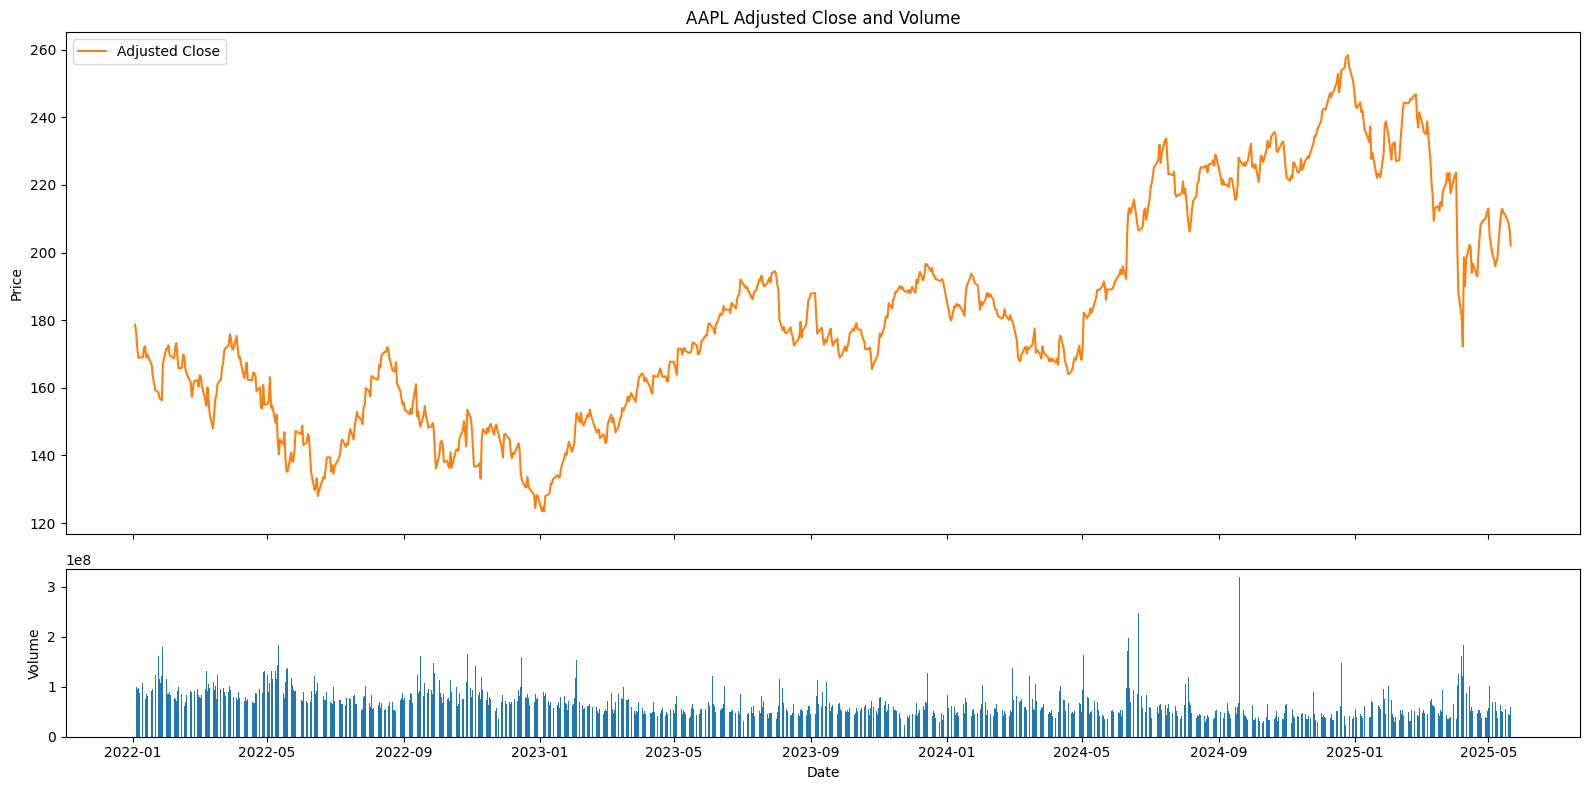

In [12]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 8), sharex=True, gridspec_kw={'height_ratios': [3, 1]})

apple_df = equity_filtered_df[equity_filtered_df.symbol == 'AAPL']

# Plot OHLC
# ax1.plot(apple_df.date, apple_df['open'], label='Open', color='tab:blue')
# ax1.plot(apple_df.date, apple_df['high'], label='High', color='tab:green')
# ax1.plot(apple_df.date, apple_df['low'], label='Low', color='tab:red')
ax1.plot(apple_df.date, apple_df['adj_close'], label='Adjusted Close', color='tab:orange')
ax1.set_ylabel('Price')
ax1.legend(loc='upper left')
ax1.set_title('AAPL Adjusted Close and Volume')

# Plot Volume
ax2.bar(apple_df.date, apple_df.volume)
ax2.set_ylabel('Volume')
ax2.set_xlabel('Date')

plt.tight_layout()
plt.show()

### Bond

In [13]:
if os.path.exists(BOND_RAW_DATA_FILE):
    bond_init_df = pd.read_csv(BOND_RAW_DATA_FILE)
    bond_init_df.drop(columns='Unnamed: 0', inplace=True)
else:
    ds = load_dataset(BOND_REPO_ID)
    training_set = ds['train']
    bond_init_df = training_set.to_pandas()
    bond_init_df.to_csv(BOND_RAW_DATA_FILE)

bond_init_df.sort_values(by='date', inplace=True)

In [14]:
print("DataFrame shape:", bond_init_df.shape)

DataFrame shape: (1357417, 7)


In [15]:
print("Dataframe info:")
print(bond_init_df.info())

Dataframe info:
<class 'pandas.core.frame.DataFrame'>
Index: 1357417 entries, 816304 to 1357416
Data columns (total 7 columns):
 #   Column  Non-Null Count    Dtype  
---  ------  --------------    -----  
 0   symbol  1357417 non-null  object 
 1   date    1357417 non-null  object 
 2   open    1357417 non-null  float64
 3   high    1357417 non-null  float64
 4   low     1357417 non-null  float64
 5   close   1357417 non-null  float64
 6   volume  1357417 non-null  int64  
dtypes: float64(4), int64(1), object(2)
memory usage: 82.9+ MB
None


In [16]:
print("First few rows:")
print(bond_init_df.head())

First few rows:
       symbol        date  open  high   low  close  volume
816304  JP10Y  1969-04-30  7.07  7.07  7.07   7.07       0
816305  JP10Y  1969-05-30  7.08  7.08  7.08   7.08       0
816306  JP10Y  1969-06-30  7.09  7.09  7.09   7.09       0
816307  JP10Y  1969-07-31  7.08  7.08  7.08   7.08       0
816308  JP10Y  1969-08-29  7.09  7.09  7.09   7.09       0


In [17]:
bond_init_df['date'] = pd.to_datetime(bond_init_df['date'])

In [18]:
bond_filtered_df = bond_init_df[bond_init_df['symbol'].isin(BOND_TICKERS)]

In [19]:
bond_filtered_df = bond_filtered_df[(bond_filtered_df['date'] >= FILTER_DATE_START) & (bond_filtered_df['date'] <= FILTER_DATE_END)]

In [20]:
print(bond_filtered_df.shape)

(878, 7)


In [21]:
bond_filtered_df.head()

,symbol,date,open,high,low,close,volume
1200338,US10Y,2022-01-03,1.531,1.642,1.529,1.630,0
1200339,US10Y,2022-01-04,1.617,1.686,1.614,1.666,0
1200340,US10Y,2022-01-05,1.656,1.712,1.640,1.703,0
1200341,US10Y,2022-01-06,1.700,1.753,1.686,1.733,0
1200342,US10Y,2022-01-07,1.725,1.801,1.711,1.769,0


In [22]:
bond_filtered_df.isna().sum()

symbol    0
date      0
open      0
high      0
low       0
close     0
volume    0
dtype: int64

In [23]:
bond_filtered_df.head()

,symbol,date,open,high,low,close,volume
1200338,US10Y,2022-01-03,1.531,1.642,1.529,1.630,0
1200339,US10Y,2022-01-04,1.617,1.686,1.614,1.666,0
1200340,US10Y,2022-01-05,1.656,1.712,1.640,1.703,0
1200341,US10Y,2022-01-06,1.700,1.753,1.686,1.733,0
1200342,US10Y,2022-01-07,1.725,1.801,1.711,1.769,0


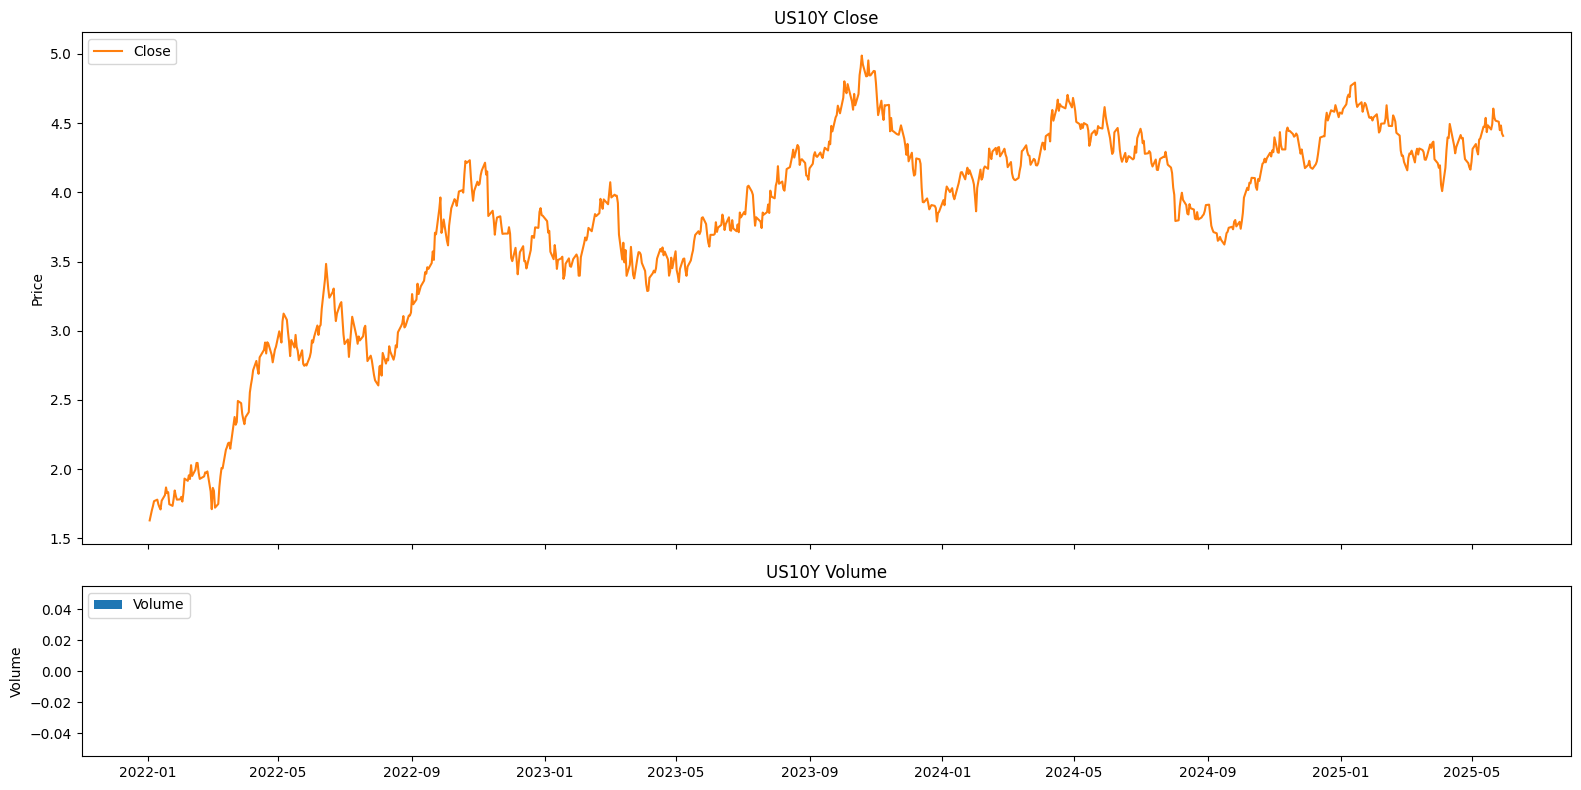

In [24]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 8), sharex=True, gridspec_kw={'height_ratios': [3, 1]})

# Plot Close and Volume by Date
ax1.plot(bond_filtered_df.date, bond_filtered_df['close'], label='Close', color='tab:orange')
ax1.set_ylabel('Price')
ax1.legend(loc='upper left')
ax1.set_title('US10Y Close')

ax2.bar(bond_filtered_df.date, bond_filtered_df['volume'], label='Volume', color='tab:blue')
ax2.set_ylabel('Volume')
ax2.legend(loc='upper left')
ax2.set_title('US10Y Volume')

plt.tight_layout()
plt.show()

## Feature Engineering

In [25]:
def PrepareEquityData(init_df, scaler, window_size=7):
    """ Prepare the data for training the model.  """
    # df = init_df[init_df.symbol == "AAPL"].copy()
    df = init_df.copy()
    df = df[['date', 'adj_close']]

    # Reset index to make datetime a column if needed for processing
    df.date = pd.to_datetime(df.date)
    df.set_index(keys=['date'], inplace=True)
    if 'date' not in df.columns:
        df.reset_index(inplace=True)

    # target_dates = df.index[window_size:]
    target_dates = df['date'][window_size:].values

    # Fill NaN values that may be created by technical indicators
    # Handle missing values, ie weekends/holidays
    df = df.bfill().ffill()

    # Setup Feature Columns
    feature_columns = ['adj_close']

    # Ensure all feature columns are float type
    for col in feature_columns:
        df[col] = df[col].astype(np.float32)

    df_reshaped = df['adj_close'].astype(np.float32).values.reshape(-1, 1)

    # Scale the data 
    df_scaled = scaler.fit_transform(df_reshaped)

    X = []
    y = []
    for i in range(window_size, len(df_scaled)):
        X.append(df_scaled[i - window_size:i, 0])
        y.append(df_scaled[i, 0])

    X = np.array(X)
    y = np.array(y)

    X_train, X_test, y_train, y_test, dates_train, dates_test = \
        train_test_split(X, y, target_dates, test_size=0.2, shuffle=False, random_state=RANDOM_STATE)

    X_train = X_train.reshape((X_train.shape[0], X_train.shape[1], 1))
    X_test = X_test.reshape((X_test.shape[0], X_test.shape[1], 1))

    return X_train, X_test, y_train, y_test, dates_train, dates_test

In [26]:
def PrepareBondData(bond_filtered_df, bond_scaler, window_size):
    # Scale the bond data
    bond_filtered_df['close_scaled'] = bond_scaler.fit_transform(bond_filtered_df[['close']])

    bond_filtered_df.fillna(method='ffill', inplace=True)
    bond_filtered_df.fillna(method='bfill', inplace=True)
    
    bond_data = bond_filtered_df['close_scaled'].values

    # Create sequences
    X, y, dates = [], [], []
    for i in range(len(bond_data) - window_size):
        X.append(bond_data[i:i + window_size])
        y.append(bond_data[i + window_size])
        dates.append(bond_filtered_df['date'].iloc[i + window_size])

    # Split the data into training and test sets
    split_idx = int(len(X) * 0.8)
    X_train, X_test = np.array(X[:split_idx]), np.array(X[split_idx:])
    y_train, y_test = np.array(y[:split_idx]), np.array(y[split_idx:])
    dates_train, dates_test = np.array(dates[:split_idx]), np.array(dates[split_idx:])

    X_train = X_train.reshape((X_train.shape[0], X_train.shape[1], 1))
    X_test = X_test.reshape((X_test.shape[0], X_test.shape[1], 1))

    return X_train, X_test, y_train, y_test, dates_train, dates_test

## Long Short Term Memory (LSTM) Model

### LSTM For Equities

#### Model Training

In [27]:
class PrintLossCallback(tf.keras.callbacks.Callback):
    def on_batch_end(self, batch, logs=None):
        # if batch % 100 == 0:  # Print every 100 batches
        print(f"Batch {batch}: Loss = {logs['loss']:.4f}")

In [28]:
def GetTrainedModel(x_train, y_train, batch_size, epochs, lstm_units, window_size):
    model = Sequential()
    model.add(LSTM(lstm_units, return_sequences=True, input_shape=(window_size, x_train.shape[2])))
    model.add(Dropout(0.3))
    model.add(LSTM(lstm_units * 2, return_sequences=True))
    model.add(Dropout(0.3))
    model.add(LSTM(lstm_units, return_sequences=False))
    model.add(Dropout(0.3))
    model.add(Dense(20))
    model.add(Dense(1))

    model.compile(loss='mean_squared_error',
                  optimizer='adam',
                  # metrics=[
                  #   tf.keras.metrics.BinaryAccuracy(),
                  #   tf.keras.metrics.FalseNegatives(),
                  # ]
                )

    es_callback = tf.keras.callbacks.EarlyStopping(monitor='loss', patience=PATIENCE, verbose=0)

    model.fit(x_train, y_train,
              batch_size=batch_size,
              epochs=epochs,
              callbacks=[es_callback], # PrintLossCallback()],
              verbose="1", )

    model.summary()

    return model

In [29]:
def random_search(x_train, y_train, num_iterations=10):
    best_loss = float('inf')
    best_params = None

    for _ in range(num_iterations):
        batch_size = random.choice([8, 16, 32])
        epochs = random.choice([50, 100, 150])
        lstm_units = random.choice([50, 100, 150])

        print(f"Trying batch_size={batch_size}, epochs={epochs}, lstm_units={lstm_units}")
        model = GetTrainedModel(x_train, y_train, batch_size, epochs, lstm_units, WINDOW_SIZE)
        loss = model.evaluate(x_train, y_train, verbose=0)

        if loss < best_loss:
            best_loss = loss
            best_params = (batch_size, epochs, lstm_units)
        
        print(f"Loss of previous evaluation {loss}")


    print(f"Best params: batch_size={best_params[0]}, epochs={best_params[1]}, lstm_units={best_params[2]} with loss={best_loss}")
    return best_params

In [30]:
# To scale the data
equity_scaler = MinMaxScaler()

# Get the prepared data
X_train_equity, X_test_equity, y_train_equity, y_test_equity, dates_train_equity, dates_test_equity = \
    PrepareEquityData(equity_filtered_df, equity_scaler, WINDOW_SIZE)

print(f"Training data shape: X={X_train_equity.shape}, Y={y_train_equity.shape}")

Training data shape: X=(673, 7, 1), Y=(673,)


In [31]:
KERAS_MODEL="./models/F0_best_equity_model.keras"
if os.path.exists(KERAS_MODEL):
    equity_model = tf.keras.models.load_model(KERAS_MODEL)
else:
    print("\nPerforming random search for optimal parameters...")
    equity_params = random_search(X_train_equity, y_train_equity)

    print(f"Best parameters found: {equity_params}")

    print("\nTraining model with best parameters...")
    equity_model = GetTrainedModel(X_train_equity, y_train_equity, WINDOW_SIZE, *equity_params)

    # Save the model trained with the best parameters
    equity_model.save(KERAS_MODEL)


Performing random search for optimal parameters...
Trying batch_size=8, epochs=100, lstm_units=100
Epoch 1/100


/Users/jrizzo/Projects/courses/EE595/.venv/lib/python3.12/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 2/100
Epoch 3/100
Epoch 4/100
Epoch 5/100
Epoch 6/100
Epoch 7/100
Epoch 8/100
Epoch 9/100
Epoch 10/100
Epoch 11/100
Epoch 12/100
Epoch 13/100
Epoch 14/100
Epoch 15/100
Epoch 16/100
Epoch 17/100
Epoch 18/100
Epoch 19/100
Epoch 20/100
Epoch 21/100
Epoch 22/100
Epoch 23/100
Epoch 24/100
Epoch 25/100
Epoch 26/100
Epoch 27/100
Epoch 28/100
Epoch 29/100


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 7, 100)         │        40,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 7, 100)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 7, 200)         │       240,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 7, 200)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 100)            │       120,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 20)             │         2,020 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            21 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_30 (LSTM)                  │ (None, 150, 100)       │        40,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_30 (Dropout)            │ (None, 150, 100)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_31 (LSTM)                  │ (None, 150, 200)       │       240,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_31 (Dropout)            │ (None, 150, 200)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_32 (LSTM)                  │ (None, 100)            │       120,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_32 (Dropout)            │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ (None, 20)             │         2,020 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ (None, 1)              │            21 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,212,125 (4.62 MB)

 Trainable params: 404,041 (1.54 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 808,084 (3.08 MB)

In [32]:
# plot_model(equity_model, show_shapes=True, show_layer_names=True)

#### Model Prediction

In [33]:
print("\nMaking prediction...")
equity_predictions = []
equity_predictions = equity_model.predict(X_test_equity)
equity_predictions = equity_scaler.inverse_transform(equity_predictions).flatten()
y_test_equity = equity_scaler.inverse_transform(y_test_equity.reshape(-1, 1)).flatten()


Making prediction...
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step


In [34]:
# Calculating the RMSE to compare against other models
rmse=np.sqrt(np.mean((y_test_equity - equity_predictions)**2))
print(f'RMSE: {rmse:.2f}')

RMSE: 7.63


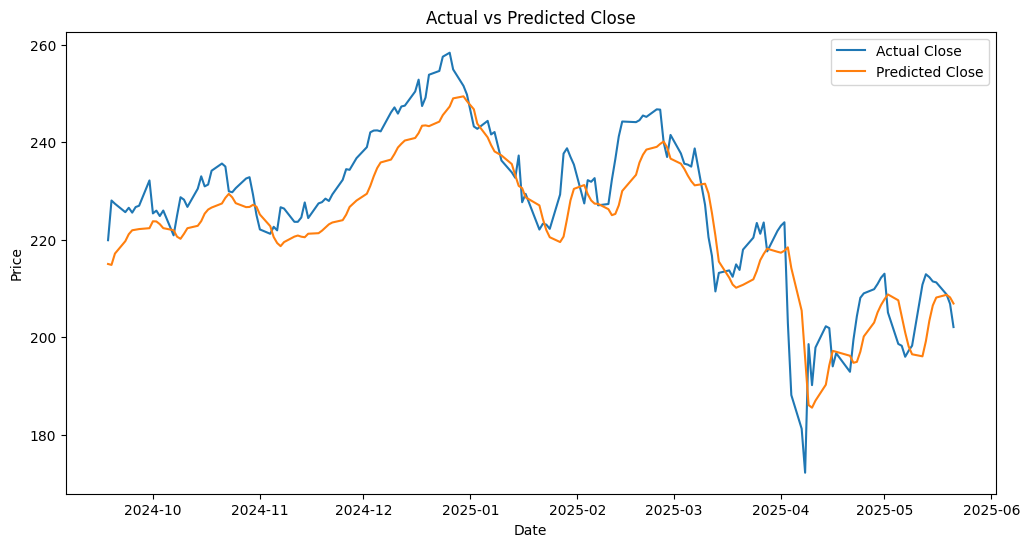

In [35]:
plt.figure(figsize=(12, 6))
plt.plot(dates_test_equity, y_test_equity, label='Actual Close')
plt.plot(dates_test_equity, equity_predictions, label='Predicted Close')
plt.title('Actual vs Predicted Close')
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend()
plt.show()

### LSTM for Bonds

#### Model Training

In [36]:
bond_scaler = MinMaxScaler()

X_train_bond, X_test_bond, y_train_bond, y_test_bond, dates_train_bond, dates_test_bond = \
    PrepareBondData(bond_filtered_df, bond_scaler, WINDOW_SIZE)

print(f"Training data shape: X={X_train_bond.shape}, Y={y_train_bond.shape}")

Training data shape: X=(696, 7, 1), Y=(696,)


/var/folders/xd/kx89201x40lczm02gsvb4yym0000gn/T/ipykernel_20778/2170867812.py:5: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  bond_filtered_df.fillna(method='ffill', inplace=True)
/var/folders/xd/kx89201x40lczm02gsvb4yym0000gn/T/ipykernel_20778/2170867812.py:6: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  bond_filtered_df.fillna(method='bfill', inplace=True)


In [37]:
KERAS_MODEL="./models/F0_best_bond_model.keras"
if os.path.exists(KERAS_MODEL):
    bond_model = tf.keras.models.load_model(KERAS_MODEL)
else:
    print("\nPerforming random search for optimal parameters...")
    bond_best_params = random_search(X_train_bond, y_train_bond)
    
    print("\nTraining model with best parameters...")
    bond_model = GetTrainedModel(X_train_bond, y_train_bond, WINDOW_SIZE, *bond_best_params)

    # Save the model trained with the best parameters
    bond_model.save(KERAS_MODEL)


Performing random search for optimal parameters...
Trying batch_size=32, epochs=100, lstm_units=150
Epoch 1/100


/Users/jrizzo/Projects/courses/EE595/.venv/lib/python3.12/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 2/100
Epoch 3/100
Epoch 4/100
Epoch 5/100
Epoch 6/100
Epoch 7/100
Epoch 8/100
Epoch 9/100
Epoch 10/100
Epoch 11/100
Epoch 12/100
Epoch 13/100
Epoch 14/100
Epoch 15/100
Epoch 16/100
Epoch 17/100
Epoch 18/100
Epoch 19/100


Model: "sequential_11"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_33 (LSTM)                  │ (None, 7, 150)         │        91,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_33 (Dropout)            │ (None, 7, 150)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_34 (LSTM)                  │ (None, 7, 300)         │       541,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_34 (Dropout)            │ (None, 7, 300)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_35 (LSTM)                  │ (None, 150)            │       270,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_35 (Dropout)            │ (None, 150)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ (None, 20)             │         3,020 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_23 (Dense)                │ (None, 1)              │            21 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_63 (LSTM)                  │ (None, 100, 50)        │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_63 (Dropout)            │ (None, 100, 50)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_64 (LSTM)                  │ (None, 100, 100)       │        60,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_64 (Dropout)            │ (None, 100, 100)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_65 (LSTM)                  │ (None, 50)             │        30,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_65 (Dropout)            │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_42 (Dense)                │ (None, 20)             │         1,020 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_43 (Dense)                │ (None, 1)              │            21 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 306,125 (1.17 MB)

 Trainable params: 102,041 (398.60 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 204,084 (797.21 KB)

#### Model Prediction

In [38]:
print("\nMaking prediction...")
bond_predictions = []
bond_predictions = bond_model.predict(X_test_bond)
bond_predictions = bond_scaler.inverse_transform(bond_predictions).flatten()
y_test_bond = bond_scaler.inverse_transform(y_test_bond.reshape(-1, 1)).flatten()


Making prediction...
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step


In [39]:
rmse = np.sqrt(np.mean((y_test_bond - bond_predictions)**2))
print(f'RMSE: {rmse:.2f}')

RMSE: 0.10


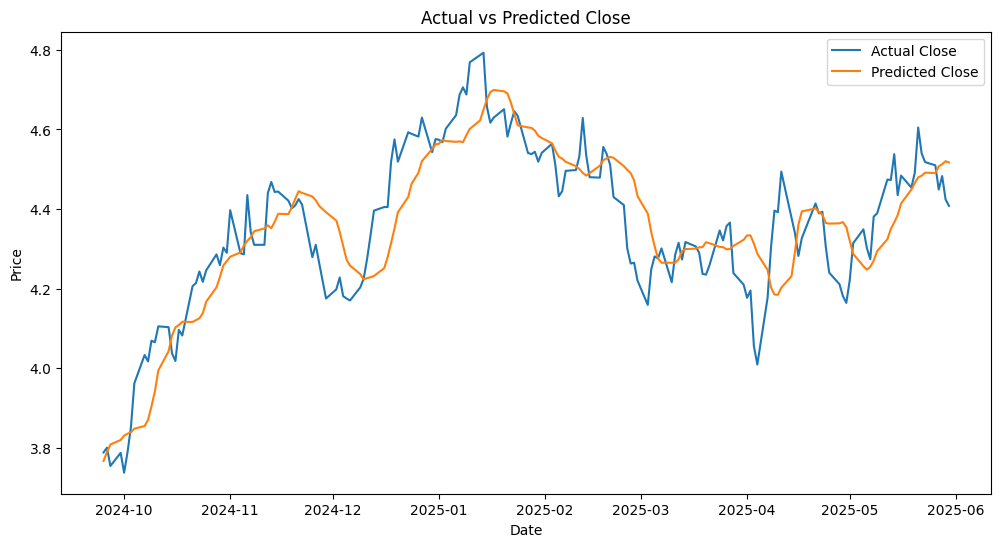

In [40]:
plt.figure(figsize=(12, 6))
plt.plot(dates_test_bond, y_test_bond, label='Actual Close')
plt.plot(dates_test_bond, bond_predictions, label='Predicted Close')
plt.title('Actual vs Predicted Close')
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend()
plt.show()

## Patch Time Series Transformer (PatchTST) Model

### PatchTST for Equities

In [41]:
df = equity_filtered_df[equity_filtered_df.symbol == "AAPL"]
df.sort_values(by='date', inplace=True)

equity_scaler = MinMaxScaler()
df['close_scaled'] = equity_scaler.fit_transform(df[['close']])
data = df['close_scaled'].values

# Split the data into training and test data
train_data = data[:-90]
test_data = data[-(INPUT_LEN + FORECAST_LEN):]

In [42]:
class TimeSeriesDataset(Dataset):
    def __init__(self, series, input_len, forecast_len):
        self.series = series
        self.input_len = input_len
        self.forecast_len = forecast_len

    def __len__(self):
        return len(self.series) - self.input_len - self.forecast_len

    def __getitem__(self, idx):
        x = self.series[idx:idx + self.input_len]
        y = self.series[idx + self.input_len:idx + self.input_len + self.forecast_len]
        return torch.tensor(x, dtype=torch.float32).unsqueeze(-1), torch.tensor(y, dtype=torch.float32)

In [43]:
train_dataset = TimeSeriesDataset(train_data, INPUT_LEN, FORECAST_LEN)
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)

#### Model Training

In [44]:
class EquityPatchTST(nn.Module):
    def __init__(self, input_len, forecast_len, n_features, patch_len=16, n_heads=4, d_model=64, dropout=0.1):
        super().__init__()
        self.n_patches = input_len // patch_len
        self.patch_len = patch_len
        self.embedding = nn.Linear(patch_len * n_features, d_model)
        self.positional_encoding = nn.Parameter(torch.randn(1, self.n_patches, d_model))
        encoder_layer = nn.TransformerEncoderLayer(d_model=d_model, nhead=n_heads, dropout=dropout, batch_first=True)
        self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=2)
        self.head = nn.Sequential(
            nn.Flatten(),
            nn.Linear(d_model * self.n_patches, forecast_len)
        )

    def forward(self, x):
        B, T, C = x.shape
        x = x.view(B, self.n_patches, self.patch_len * C)
        x = self.embedding(x) + self.positional_encoding[:, :self.n_patches]
        x = self.encoder(x)
        return self.head(x)

In [45]:
class EarlyStopping:
    def __init__(self, patience=5, delta=0, verbose=False):
        self.patience = patience
        self.delta = delta
        self.verbose = verbose
        self.best_loss = None
        self.no_improvement_count = 0
        self.stop_training = False
    
    def check_early_stop(self, val_loss):
        if self.best_loss is None or val_loss < self.best_loss - self.delta:
            self.best_loss = val_loss
            self.no_improvement_count = 0
        else:
            self.no_improvement_count += 1
            if self.no_improvement_count >= self.patience:
                self.stop_training = True
                if self.verbose:
                    print("Stopping early as no improvement has been observed.")

In [46]:
equity_model = EquityPatchTST(INPUT_LEN, FORECAST_LEN, n_features=1, patch_len=PATCH_LEN)
optimizer = torch.optim.Adam(equity_model.parameters(), lr=0.001)
criterion = nn.MSELoss()
early_stopping = EarlyStopping(patience=PATIENCE, delta=DELTA)

In [47]:
for epoch in range(EPOCHS):
    epoch_loss = 0.0
    val_loss = 0.0

    equity_model.train()
    for xb, yb in train_loader:
        optimizer.zero_grad()
        pred = equity_model(xb)
        loss = criterion(pred, yb)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()
    
    print(f"Epoch {epoch+1}/{EPOCHS}, Loss: {epoch_loss / len(train_loader):.4f}")

    # Validation phase
    equity_model.eval()
    with torch.no_grad():
        for data, target in train_loader:
            data = data #.to(device)
            target = target #.to(device)
            output = equity_model(data)
            loss = criterion(output, target)
            val_loss += loss.item()
    
    # Average validation loss
    val_loss /= len(train_loader)

    # Check early stopping condition
    early_stopping.check_early_stop(val_loss)
    
    if early_stopping.stop_training:
        print(f"Early stopping at epoch {epoch}")
        break

Epoch 1/150, Loss: 0.1712
Epoch 2/150, Loss: 0.0726
Epoch 3/150, Loss: 0.0609
Epoch 4/150, Loss: 0.0488
Epoch 5/150, Loss: 0.0365
Epoch 6/150, Loss: 0.0282
Epoch 7/150, Loss: 0.0251
Epoch 8/150, Loss: 0.0232
Epoch 9/150, Loss: 0.0209
Epoch 10/150, Loss: 0.0191
Epoch 11/150, Loss: 0.0181
Epoch 12/150, Loss: 0.0161
Epoch 13/150, Loss: 0.0160
Epoch 14/150, Loss: 0.0154
Epoch 15/150, Loss: 0.0144
Epoch 16/150, Loss: 0.0139
Epoch 17/150, Loss: 0.0144
Epoch 18/150, Loss: 0.0124
Epoch 19/150, Loss: 0.0120
Epoch 20/150, Loss: 0.0119
Epoch 21/150, Loss: 0.0112
Epoch 22/150, Loss: 0.0112
Epoch 23/150, Loss: 0.0111
Epoch 24/150, Loss: 0.0102
Epoch 25/150, Loss: 0.0108
Epoch 26/150, Loss: 0.0104
Epoch 27/150, Loss: 0.0100
Epoch 28/150, Loss: 0.0095
Epoch 29/150, Loss: 0.0100
Epoch 30/150, Loss: 0.0132
Early stopping at epoch 29


#### Model Prediction

In [48]:
equity_model.eval()
with torch.no_grad():
    test_input = torch.tensor(test_data[:INPUT_LEN], dtype=torch.float32).unsqueeze(0).unsqueeze(-1)
    pred_scaled = equity_model(test_input).squeeze().numpy()

forecast_unscaled = equity_scaler.inverse_transform(pred_scaled.reshape(-1, 1)).flatten()
actual_unscaled = equity_scaler.inverse_transform(test_data[INPUT_LEN:].reshape(-1, 1)).flatten()
forecast_dates = pd.date_range(start=df['date'].max() + pd.Timedelta(days=1), periods=FORECAST_LEN)

forecast_30 = forecast_unscaled[-30:]
actual_30 = actual_unscaled[-30:]
forecast_dates_30 = forecast_dates[-30:]

In [49]:
mae = mean_absolute_error(actual_30, forecast_30)
r2 = r2_score(actual_30, forecast_30)
rmse = mean_squared_error(actual_30, forecast_30) ** 0.5

print("Evaluation Metrics:")
print(f"MAE: {mae:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"R^2: {r2:.4f}")

Evaluation Metrics:
MAE: 12.2405
RMSE: 14.0452
R^2: -3.3680


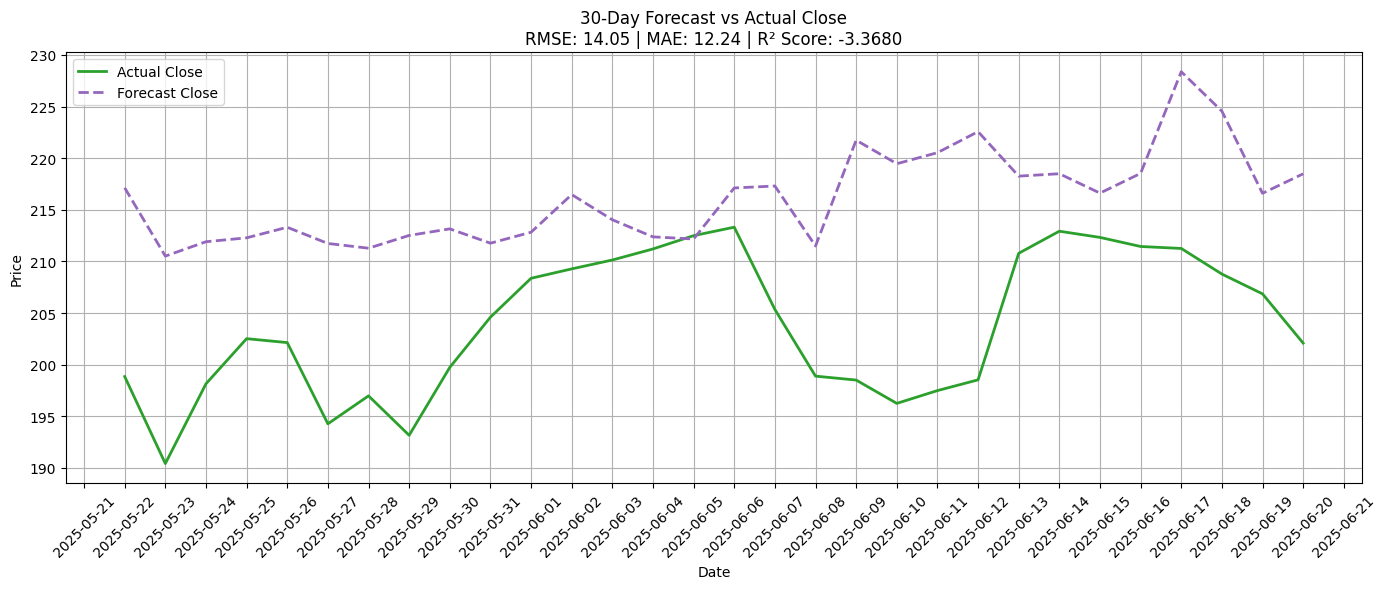

In [50]:
plt.figure(figsize=(14, 6))
plt.plot(forecast_dates_30, actual_30, label='Actual Close', color='tab:green', linewidth=2)
plt.plot(forecast_dates_30, forecast_30, label='Forecast Close', color='tab:purple', linestyle='--', linewidth=2)
plt.title(f'30-Day Forecast vs Actual Close\nRMSE: {rmse:.2f} | MAE: {mae:.2f} | R² Score: {r2:.4f}')
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend(loc='upper left')
plt.grid(True)
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
plt.gca().xaxis.set_major_locator(mdates.DayLocator(interval=1))
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### PatchTST for Bonds

In [51]:
INPUT_LEN = 90
LR = 0.0005

In [52]:
df = bond_filtered_df[bond_filtered_df.symbol == "US10Y"]
df.sort_values(by='date', inplace=True)

df['ma5'] = df['close'].rolling(window=5).mean()
df['ma20'] = df['close'].rolling(window=20).mean()
df['rsi'] = df['close'].diff().apply(lambda x: max(x, 0)).rolling(window=14).mean() / \
            df['close'].diff().abs().rolling(window=14).mean()
df = df.bfill().ffill()

features = ['open', 'high', 'low', 'close', 'volume', 'ma5', 'ma20', 'rsi']

bond_scaler = MinMaxScaler()
bond_data_scaled = bond_scaler.fit_transform(df[features].values)

# Split the data into training and test data
# train_data = bond_data_scaled[:-90]
# test_data = bond_data_scaled[-(INPUT_LEN + FORECAST_LEN):]

In [53]:
# Custom Dataset
class TimeSeriesDataset(Dataset):
    def __init__(self, data, input_len, forecast_len):
        self.data = data
        self.input_len = input_len
        self.forecast_len = forecast_len

    def __len__(self):
        return len(self.data) - self.input_len - self.forecast_len

    def __getitem__(self, idx):
        x = self.data[idx:idx + self.input_len]
        y = self.data[idx + self.input_len:idx + self.input_len + self.forecast_len, 3]
        return torch.tensor(x, dtype=torch.float32), torch.tensor(y, dtype=torch.float32)

In [54]:
train_dataset = TimeSeriesDataset(bond_data_scaled, INPUT_LEN, FORECAST_LEN)
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)

#### Model Training

In [55]:
# BondPatchTST Model
class BondPatchTST(nn.Module):
    def __init__(self, input_len, forecast_len, n_features, patch_len=16, n_heads=8, d_model=128, dropout=0.1):
        super().__init__()
        self.n_patches = input_len // patch_len
        self.patch_len = patch_len
        self.embedding = nn.Sequential(
            nn.Linear(patch_len * n_features, d_model),
            nn.LayerNorm(d_model)
        )
        self.positional_encoding = nn.Parameter(torch.randn(1, self.n_patches, d_model))
        encoder_layer = nn.TransformerEncoderLayer(d_model=d_model, nhead=n_heads, dropout=dropout, batch_first=True)
        self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=4)
        self.head = nn.Sequential(
            nn.Flatten(),
            nn.Linear(d_model * self.n_patches, forecast_len)
        )

    def forward(self, x):
        B, T, C = x.shape
        x = x.reshape(B, self.n_patches, self.patch_len * C)
        x = self.embedding(x) + self.positional_encoding[:, :self.n_patches]
        x = self.encoder(x)
        return self.head(x)

In [56]:
# Training the data
bond_model = BondPatchTST(INPUT_LEN, FORECAST_LEN, n_features=len(features), patch_len=PATCH_LEN)
optimizer = torch.optim.Adam(bond_model.parameters(), lr=LR)
criterion = nn.MSELoss()
early_stopping = EarlyStopping(patience=PATIENCE, delta=DELTA)

In [57]:
for epoch in range(EPOCHS):
    bond_model.train()
    epoch_loss = 0
    for xb, yb in train_loader:
        optimizer.zero_grad()
        pred = bond_model(xb)
        loss = criterion(pred, yb)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()
    print(f"Epoch {epoch+1}/{EPOCHS}, Loss: {epoch_loss / len(train_loader):.4f}")

    # Validation phase
    bond_model.eval()
    with torch.no_grad():
        for data, target in train_loader:
            data = data #.to(device)
            target = target #.to(device)
            output = bond_model(data)
            loss = criterion(output, target)
            val_loss += loss.item()
    
    # Average validation loss
    val_loss /= len(train_loader)

    # Check early stopping condition
    early_stopping.check_early_stop(val_loss)
    
    if early_stopping.stop_training:
        print(f"Early stopping at epoch {epoch}")
        break

Epoch 1/150, Loss: 0.1667
Epoch 2/150, Loss: 0.0432
Epoch 3/150, Loss: 0.0370
Epoch 4/150, Loss: 0.0349
Epoch 5/150, Loss: 0.0331
Epoch 6/150, Loss: 0.0302
Epoch 7/150, Loss: 0.0254
Epoch 8/150, Loss: 0.0218
Epoch 9/150, Loss: 0.0209
Epoch 10/150, Loss: 0.0198
Epoch 11/150, Loss: 0.0185
Epoch 12/150, Loss: 0.0185
Epoch 13/150, Loss: 0.0175
Epoch 14/150, Loss: 0.0171
Epoch 15/150, Loss: 0.0169
Epoch 16/150, Loss: 0.0170
Epoch 17/150, Loss: 0.0164
Epoch 18/150, Loss: 0.0154
Epoch 19/150, Loss: 0.0151
Epoch 20/150, Loss: 0.0151
Epoch 21/150, Loss: 0.0143
Epoch 22/150, Loss: 0.0147
Epoch 23/150, Loss: 0.0146
Epoch 24/150, Loss: 0.0136
Early stopping at epoch 23


#### Model Prediction

In [58]:
# Forecast
test_data = bond_data_scaled[-(INPUT_LEN + FORECAST_LEN):]
bond_model.eval()
with torch.no_grad():
    test_input = torch.tensor(test_data[:INPUT_LEN], dtype=torch.float32).unsqueeze(0)
    pred_scaled = bond_model(test_input).squeeze().numpy()

bond_forecast_unscaled = bond_scaler.inverse_transform(
    np.concatenate([np.zeros((FORECAST_LEN, 3)),
                    pred_scaled.reshape(-1, 1),
                    np.zeros((FORECAST_LEN, len(features) - 4))], axis=1)
)[:, 3]

bond_actual_unscaled = bond_scaler.inverse_transform(
    np.concatenate([np.zeros((FORECAST_LEN, 3)),
                    test_data[INPUT_LEN:, 3].reshape(-1, 1),
                    np.zeros((FORECAST_LEN, len(features) - 4))], axis=1)
)[:, 3]

bond_forecast_dates = pd.date_range(start=df['date'].max() + pd.Timedelta(days=1), periods=FORECAST_LEN)

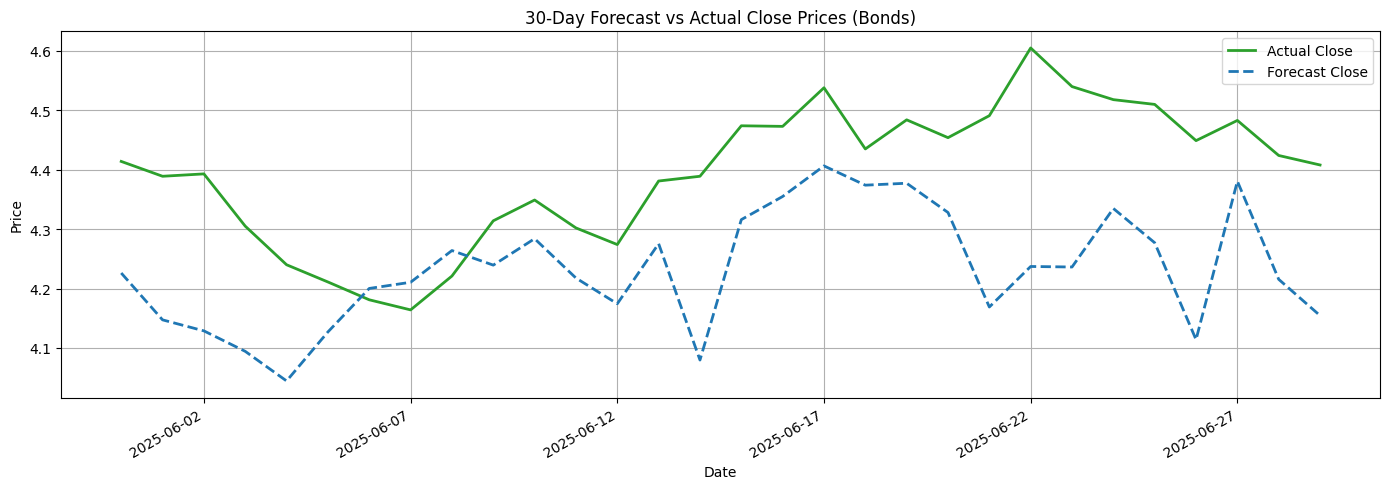

In [59]:
plt.figure(figsize=(14, 5))
plt.plot(bond_forecast_dates, bond_actual_unscaled, label='Actual Close', color='tab:green', linewidth=2)
plt.plot(bond_forecast_dates, bond_forecast_unscaled, label='Forecast Close', color='tab:blue', linestyle='--', linewidth=2)
plt.title('30-Day Forecast vs Actual Close Prices (Bonds)')
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend()
plt.grid(True)
plt.gca().xaxis.set_major_locator(mdates.DayLocator(interval=5))
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
plt.gcf().autofmt_xdate()
plt.tight_layout()
plt.show()

## Ordinary Least Squares (OLS) Model

--- Acquiring Financial Data ---


/var/folders/xd/kx89201x40lczm02gsvb4yym0000gn/T/ipykernel_20778/1469238505.py:28: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(all_tickers, start=start_date, end=end_date)['Close']
[*********************100%***********************]  4 of 4 completed

Financial data downloaded successfully.

--- Raw Combined Data Head ---
Ticker            AAPL        GOOG        MSFT        TLT
Date                                                     
2024-10-01  225.417618  167.835968  418.241638  95.376968
2024-10-02  225.985626  166.729813  414.702362  94.573196
2024-10-03  224.879517  166.630173  414.115784  93.682266
2024-10-04  226.005569  167.975479  413.638550  92.529900
2024-10-07  220.913483  163.819931  407.156525  91.832649

--- Raw Combined Data Info ---
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 120 entries, 2024-10-01 to 2025-03-25
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   AAPL    120 non-null    float64
 1   GOOG    120 non-null    float64
 2   MSFT    120 non-null    float64
 3   TLT     120 non-null    float64
dtypes: float64(4)
memory usage: 4.7 KB

--- Target KPIs Head (shifted) ---
            Avg_Tech_Return_Next_Day  Bond_Price_Change_Next_Day
Date


/var/folders/xd/kx89201x40lczm02gsvb4yym0000gn/T/ipykernel_20778/1469238505.py:122: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  full_data.fillna(method='ffill', inplace=True)
/var/folders/xd/kx89201x40lczm02gsvb4yym0000gn/T/ipykernel_20778/1469238505.py:123: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  full_data.fillna(method='bfill', inplace=True) # For any initial NaNs


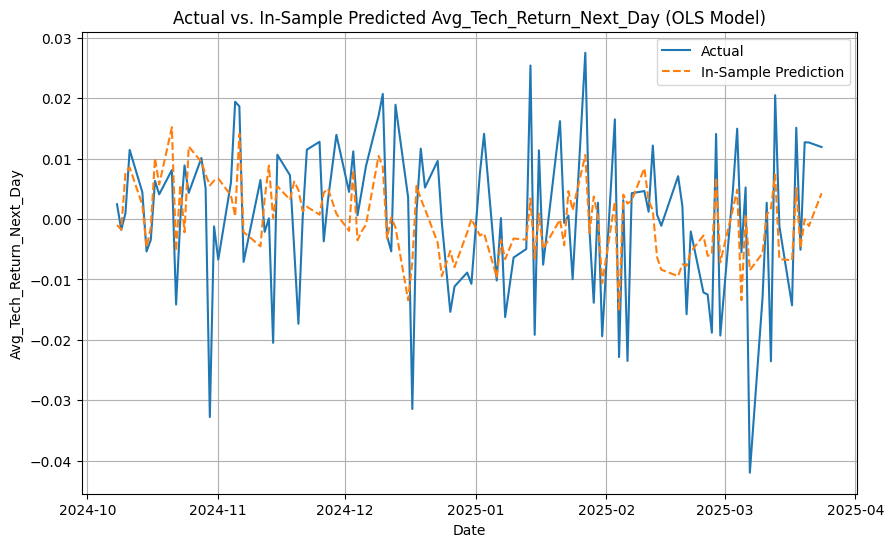


--- Training OLS Model for Bond_Price_Change_Next_Day ---
                                OLS Regression Results                                
Dep. Variable:     Bond_Price_Change_Next_Day   R-squared:                       0.286
Model:                                    OLS   Adj. R-squared:                  0.051
Method:                         Least Squares   F-statistic:                     1.215
Date:                        Sun, 06 Jul 2025   Prob (F-statistic):              0.245
Time:                                11:40:31   Log-Likelihood:                -111.53
No. Observations:                         114   AIC:                             281.1
Df Residuals:                              85   BIC:                             360.4
Df Model:                                  28                                         
Covariance Type:                    nonrobust                                         
                          coef    std err          t      P>|t|      [0

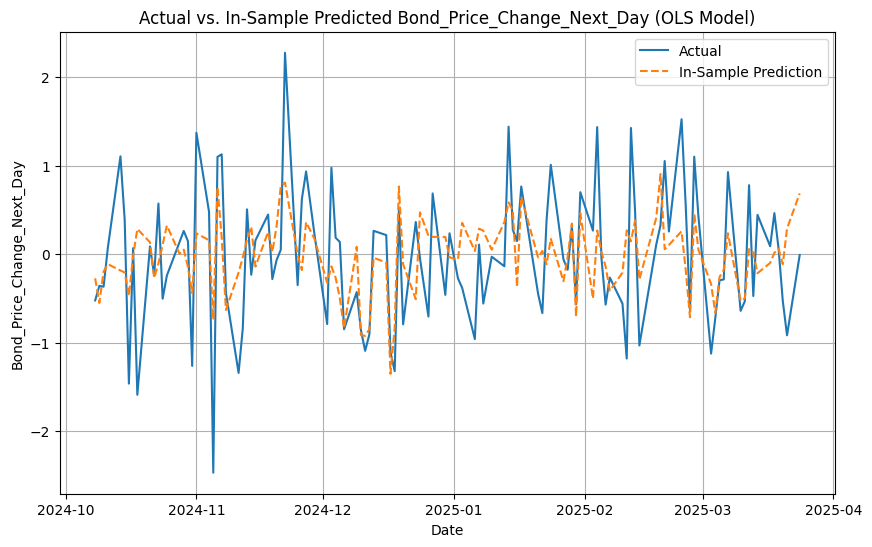


--- Demonstrating Future Prediction with the Trained OLS Models ---
Features for prediction are based on data up to 2025-03-24
Predicted Avg_Tech_Return_Next_Day for 2025-03-25: 0.0043
Predicted Bond_Price_Change_Next_Day for 2025-03-25: 0.6851

--- Important Note on Data Range ---
The data period used is from 2024-10-01 to 2025-03-26, providing significantly more data points.
This should allow the OLS models to learn more robust patterns compared to the very short previous range.
However, financial forecasting remains challenging, and the model's performance will depend on the
complexity of the patterns present in the data and the linearity assumption of OLS.


In [60]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
from datetime import datetime, timedelta
import statsmodels.api as sm # For OLS (Ordinary Least Squares)

# --- Part 1: Data Acquisition and Preprocessing ---

def get_financial_data(tickers, bond_ticker, start_date, end_date):
    """
    Downloads historical adjusted close prices for given tech stock tickers
    and a specified bond ticker.

    Args:
        tickers (list): List of stock ticker symbols (e.g., ['AAPL', 'MSFT', 'GOOGL']).
        bond_ticker (str): Ticker symbol for the bond ETF (e.g., 'TLT').
        start_date (str): Start date in 'YYYY-MM-DD' format.
        end_date (str): End date in 'YYYY-MM-DD' format.

    Returns:
        pd.DataFrame: DataFrame with 'Adj Close' prices for each ticker (stocks and bond).
    """
    all_tickers = tickers + [bond_ticker]
    print(f"Downloading financial data for {all_tickers} from {start_date} to {end_date}...")
   
    # Download 'Close' prices for all tickers
    data = yf.download(all_tickers, start=start_date, end=end_date)['Close']
   
    # If downloading multiple tickers, 'Close' will be a MultiIndex, need to flatten
    if isinstance(data.columns, pd.MultiIndex):
        # Flatten MultiIndex columns, keeping the ticker symbol
        data.columns = [col[1] for col in data.columns]
   
    data.index = pd.to_datetime(data.index)
    print("Financial data downloaded successfully.")
    return data

def create_time_series_features(df, window_size=5, stock_cols=None, bond_col=None):
    """
    Creates time-series features like lagged values, rolling means, and daily returns.

    Args:
        df (pd.DataFrame): Input DataFrame with time-indexed data.
        window_size (int): Size of the rolling window for features.
        stock_cols (list): List of column names that represent stock prices.
        bond_col (str): Name of the column that represents bond prices.

    Returns:
        pd.DataFrame: DataFrame with engineered features.
    """
    print(f"Creating time-series features with window size {window_size}...")
    df_features = df.copy()

    for col in df.columns:
        # Lagged features
        for i in range(1, window_size + 1):
            df_features[f'{col}_lag_{i}'] = df[col].shift(i)

        # Rolling mean
        df_features[f'{col}_rolling_mean_{window_size}'] = df[col].rolling(window=window_size).mean()

        # Daily Returns (percentage change) - for stock and bond prices
        if stock_cols and col in stock_cols or bond_col and col == bond_col:
            df_features[f'{col}_daily_return'] = df[col].pct_change()

    # Drop rows with NaN values created by lagging/rolling operations
    df_features.dropna(inplace=True)
    print("Features created and NaN rows dropped.")
    return df_features

# --- Part 2: Linear Regression Modeling with statsmodels.api.OLS ---

def train_and_predict_ols(X_data, y_data):
    """
    Trains an Ordinary Least Squares (OLS) regression model
    using statsmodels and makes a prediction for a single new data point.

    Args:
        X_data (pd.DataFrame): DataFrame of features.
        y_data (pd.Series): Series of target values.

    Returns:
        tuple: (fitted_model, in_sample_predictions)
    """
    print(f"\n--- Training OLS Model for {y_data.name} ---")

    # Add a constant (intercept) to the features, which is good practice for OLS
    X_data = sm.add_constant(X_data)

    model = sm.OLS(y_data, X_data)
    fitted_model = model.fit()
    print(fitted_model.summary())

    in_sample_predictions = fitted_model.predict(X_data)
    return fitted_model, in_sample_predictions

# --- Main Execution ---

if __name__ == "__main__":
    # Define data period
    start_date = "2024-10-01"
    end_date = "2025-03-26"

    # Tech stock tickers
    tech_tickers = ['AAPL', 'MSFT', 'GOOG'] # Apple, Microsoft, Alphabet (Google)
    # Real Bond ETF ticker (iShares 20+ Year Treasury Bond ETF)
    bond_ticker = 'TLT'
    bond_col_name = 'TLT' # This will be the column name for bond prices

    # 1. Acquire Data
    print("--- Acquiring Financial Data ---")
    full_data = get_financial_data(tech_tickers, bond_ticker, start_date, end_date)

    # Ensure all required columns are present after download
    required_cols = tech_tickers + [bond_col_name]
    if not all(col in full_data.columns for col in required_cols):
        print(f"Error: Not all required columns ({required_cols}) found in downloaded data. Available columns: {full_data.columns}")
        exit()

    # Fill any missing data (e.g., weekends/holidays for stocks) using forward fill
    full_data.fillna(method='ffill', inplace=True)
    full_data.fillna(method='bfill', inplace=True) # For any initial NaNs

    if full_data.isnull().sum().sum() > 0:
        print("Warning: Missing values still present after fillna. Check data or dates.")
        print(full_data.isnull().sum())
        full_data.dropna(inplace=True) # Drop any remaining NaNs

    print("\n--- Raw Combined Data Head ---")
    print(full_data.head())
    print("\n--- Raw Combined Data Info ---")
    full_data.info()

    # 2. Define KPIs and Engineer Features
    # KPIs:
    # 1. Next day's average tech stock return
    # 2. Next day's Bond Price change (simple difference)

    # Calculate daily returns for tech stocks to get an average
    stock_returns = full_data[tech_tickers].pct_change().mean(axis=1) # Mean daily return across tech stocks
    stock_returns.name = 'Avg_Tech_Return' # Name the series for clarity

    # Calculate Bond Price change
    bond_price_change = full_data[bond_col_name].diff() # Simple daily change in bond price
    bond_price_change.name = 'Bond_Price_Change' # Name the series for clarity

    # Combine KPIs into a target DataFrame
    # Shift KPIs back to align with the features (we are predicting *future* KPIs)
    target_kpis = pd.DataFrame({
        'Avg_Tech_Return_Next_Day': stock_returns.shift(-1),
        'Bond_Price_Change_Next_Day': bond_price_change.shift(-1)
    }).dropna() # Drop the last row as its KPI cannot be calculated

    print("\n--- Target KPIs Head (shifted) ---")
    print(target_kpis.head())

    # Ensure full_data and target_kpis are aligned by index after shifts
    common_index = full_data.index.intersection(target_kpis.index)
    full_data_aligned = full_data.loc[common_index]
    target_kpis_aligned = target_kpis.loc[common_index]

    # Create features from the aligned full_data
    feature_window_size = 5 # Use 5 previous days' data to create features for prediction
    # Pass tech_tickers and bond_col_name to create_time_series_features
    features_df = create_time_series_features(full_data_aligned,
                                              window_size=feature_window_size,
                                              stock_cols=tech_tickers,
                                              bond_col=bond_col_name)

    # Align features_df with target_kpis_aligned after feature creation
    common_index_final = features_df.index.intersection(target_kpis_aligned.index)
    X = features_df.loc[common_index_final]
    y = target_kpis_aligned.loc[common_index_final]

    print(f"\nShape of X (features): {X.shape}")
    print(f"Shape of y (targets): {y.shape}")

    # Check if we have enough data after all transformations
    if X.shape[0] < 2: # Need at least 2 samples to fit any meaningful model
        print("Not enough data points after feature engineering. Adjust dates or simulation length.")
        exit()

    # 3. Build and Train OLS Models (one for each KPI)
    fitted_models = {}
    in_sample_preds = {}

    for kpi_name in y.columns:
        # Pass the full X and the specific KPI series to the OLS function
        fitted_model, in_sample_pred = train_and_predict_ols(X, y[kpi_name])
        fitted_models[kpi_name] = fitted_model
        in_sample_preds[kpi_name] = in_sample_pred

        # Plotting in-sample predictions for visual check
        plt.figure(figsize=(10, 6))
        plt.plot(y.index, y[kpi_name], label='Actual')
        plt.plot(y.index, in_sample_pred, label='In-Sample Prediction', linestyle='--')
        plt.xlabel("Date")
        plt.ylabel(kpi_name)
        plt.title(f"Actual vs. In-Sample Predicted {kpi_name} (OLS Model)")
        plt.legend()
        plt.grid(True)
        plt.show()

    # 4. Demonstrate Future Prediction
    print("\n--- Demonstrating Future Prediction with the Trained OLS Models ---")

    # To predict future KPIs, you need the last *row* of engineered features
    # from your historical data. This row will be the input for the next time step.
    last_known_features_df = X.iloc[-1:] # Get the last row of the features DataFrame
    print(f"Features for prediction are based on data up to {last_known_features_df.index[0].strftime('%Y-%m-%d')}")

    # Add the constant term for prediction, just like during training
    last_known_features_with_const = sm.add_constant(last_known_features_df, has_constant='add')

    predicted_kpis = {}
    # Determine the date for the predicted KPIs (the day after the last feature date)
    predicted_date = last_known_features_df.index[0] + timedelta(days=1)
    # Adjust for weekends/holidays to get to the next business day
    while predicted_date.weekday() > 4: # Monday=0, Sunday=6
        predicted_date += timedelta(days=1)

    for kpi_name, model in fitted_models.items():
        prediction = model.predict(last_known_features_with_const).iloc[0]
        predicted_kpis[kpi_name] = prediction
        print(f"Predicted {kpi_name} for {predicted_date.strftime('%Y-%m-%d')}: {prediction:.4f}")

    print("\n--- Important Note on Data Range ---")
    print(f"The data period used is from {start_date} to {end_date}, providing significantly more data points.")
    print("This should allow the OLS models to learn more robust patterns compared to the very short previous range.")
    print("However, financial forecasting remains challenging, and the model's performance will depend on the")
    print("complexity of the patterns present in the data and the linearity assumption of OLS.")